In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pickle
import os
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


## Load Pre-trained Components

Load all the saved components from the `modules` folder.

In [3]:
# Path to modules folder
MODULES_PATH = Path('../modules')

# Verify all required files exist
required_files = [
    'vgg16_label_encoder.pkl',
    'vgg16_scaler.pkl', 
    'vgg16_pca.pkl',
    'vgg16_svm_model.pkl',
    'vgg16_random_forest_model.pkl'
]

print("Checking required files:")
for f in required_files:
    exists = (MODULES_PATH / f).exists()
    status = "✓" if exists else "✗"
    print(f"  {status} {f}")

Checking required files:
  ✓ vgg16_label_encoder.pkl
  ✓ vgg16_scaler.pkl
  ✓ vgg16_pca.pkl
  ✓ vgg16_svm_model.pkl
  ✓ vgg16_random_forest_model.pkl


In [4]:
# Load VGG16 model for feature extraction
print("Loading VGG16 model...")
base_model = VGG16(weights='imagenet', include_top=True)
feature_extractor = tf.keras.Model(
    inputs=base_model.input, 
    outputs=base_model.get_layer('fc2').output
)
print(f"  ✓ VGG16 loaded - Output shape: {feature_extractor.output_shape}")

Loading VGG16 model...
  ✓ VGG16 loaded - Output shape: (None, 4096)
  ✓ VGG16 loaded - Output shape: (None, 4096)


In [5]:
# Load Label Encoder
with open(MODULES_PATH / 'vgg16_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
print(f"✓ Label Encoder loaded")
print(f"  Classes: {list(label_encoder.classes_)}")

✓ Label Encoder loaded
  Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [6]:
# Load StandardScaler
with open(MODULES_PATH / 'vgg16_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print(f"✓ StandardScaler loaded")

✓ StandardScaler loaded


In [7]:
# Load PCA
with open(MODULES_PATH / 'vgg16_pca.pkl', 'rb') as f:
    pca = pickle.load(f)
print(f"✓ PCA loaded")
print(f"  Components: {pca.n_components_}")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

✓ PCA loaded
  Components: 500
  Explained variance ratio: 0.7849


In [8]:
# Load SVM Model
with open(MODULES_PATH / 'vgg16_svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)
print(f"✓ SVM Model loaded")
if hasattr(svm_model, 'best_params_'):
    print(f"  Best params: {svm_model.best_params_}")

✓ SVM Model loaded


In [9]:
# Load Random Forest Model
with open(MODULES_PATH / 'vgg16_random_forest_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
print(f"✓ Random Forest Model loaded")
if hasattr(rf_model, 'best_params_'):
    print(f"  Best params: {rf_model.best_params_}")

✓ Random Forest Model loaded
  Best params: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 300}


## Define Prediction Functions

In [10]:
def preprocess_image(image_path, img_size=(224, 224)):
    """
    Load and preprocess an image for VGG16.
    
    Args:
        image_path: Path to the image file
        img_size: Target size (width, height)
        
    Returns:
        Preprocessed image array, original image for display
    """
    # Read image
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Keep original for display
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to VGG16 input size
    img_resized = cv2.resize(img, img_size)
    
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Add batch dimension and preprocess for VGG16
    img_preprocessed = vgg_preprocess(np.expand_dims(img_rgb, axis=0))
    
    return img_preprocessed, img_display


def predict_animal(image_path, model='svm'):
    """
    Predict the animal class for an image.
    
    Args:
        image_path: Path to the image file
        model: 'svm' or 'rf' (random forest)
        
    Returns:
        Dictionary with prediction results
    """
    # Select classifier
    classifier = svm_model if model == 'svm' else rf_model
    
    # Step 1: Preprocess image
    img_preprocessed, img_display = preprocess_image(image_path)
    
    # Step 2: Extract VGG16 features
    features = feature_extractor.predict(img_preprocessed, verbose=0)
    
    # Step 3: Scale features
    features_scaled = scaler.transform(features)
    
    # Step 4: Apply PCA
    features_pca = pca.transform(features_scaled)
    
    # Step 5: Predict
    prediction_encoded = classifier.predict(features_pca)
    
    # Step 6: Decode label
    prediction_label = label_encoder.inverse_transform(prediction_encoded)[0]
    
    # Get prediction probabilities if available
    proba = None
    if hasattr(classifier, 'predict_proba'):
        proba = classifier.predict_proba(features_pca)[0]
    elif hasattr(classifier, 'best_estimator_') and hasattr(classifier.best_estimator_, 'predict_proba'):
        proba = classifier.best_estimator_.predict_proba(features_pca)[0]
    
    return {
        'predicted_class': prediction_label,
        'probabilities': proba,
        'image_display': img_display,
        'model_used': model.upper()
    }


def display_prediction(result, figsize=(12, 5)):
    """
    Display prediction result with image and probability chart.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Display image
    axes[0].imshow(result['image_display'])
    axes[0].set_title(f"Predicted: {result['predicted_class'].upper()}\n({result['model_used']} Model)", 
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Display probabilities if available
    if result['probabilities'] is not None:
        classes = label_encoder.classes_
        probs = result['probabilities']
        
        # Sort by probability
        sorted_idx = np.argsort(probs)[::-1]
        
        colors = ['green' if classes[i] == result['predicted_class'] else 'steelblue' 
                  for i in sorted_idx]
        
        axes[1].barh([classes[i] for i in sorted_idx], 
                    [probs[i] * 100 for i in sorted_idx],
                    color=colors)
        axes[1].set_xlabel('Probability (%)')
        axes[1].set_title('Class Probabilities')
        axes[1].set_xlim(0, 100)
        
        # Add percentage labels
        for i, idx in enumerate(sorted_idx):
            axes[1].text(probs[idx] * 100 + 1, i, f'{probs[idx]*100:.1f}%', 
                        va='center', fontsize=9)
    else:
        axes[1].text(0.5, 0.5, 'Probabilities not available\nfor this model', 
                    ha='center', va='center', fontsize=12)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 Prediction: {result['predicted_class'].upper()}")
    if result['probabilities'] is not None:
        print(f"📊 Confidence: {max(result['probabilities'])*100:.2f}%")

## Make Predictions

Replace `IMAGE_PATH` with the path to your image.

In [12]:
# ===== SET YOUR IMAGE PATH HERE =====
IMAGE_PATH = '../demo_imgs/10.jpeg'  # <-- Replace with your image path
# =====================================

# Check if file exists
if os.path.exists(IMAGE_PATH):
    print(f"Image found: {IMAGE_PATH}")
else:
    print(f"⚠️ Image not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH with a valid image path.")

Image found: ../demo_imgs/10.jpeg


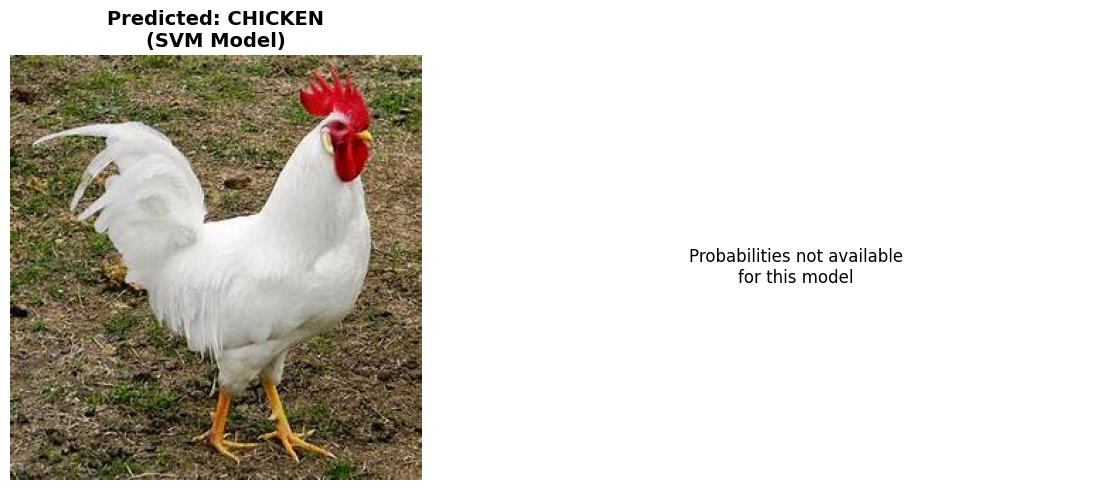


🎯 Prediction: CHICKEN


In [13]:
# Predict using SVM
if os.path.exists(IMAGE_PATH):
    result_svm = predict_animal(IMAGE_PATH, model='svm')
    display_prediction(result_svm)

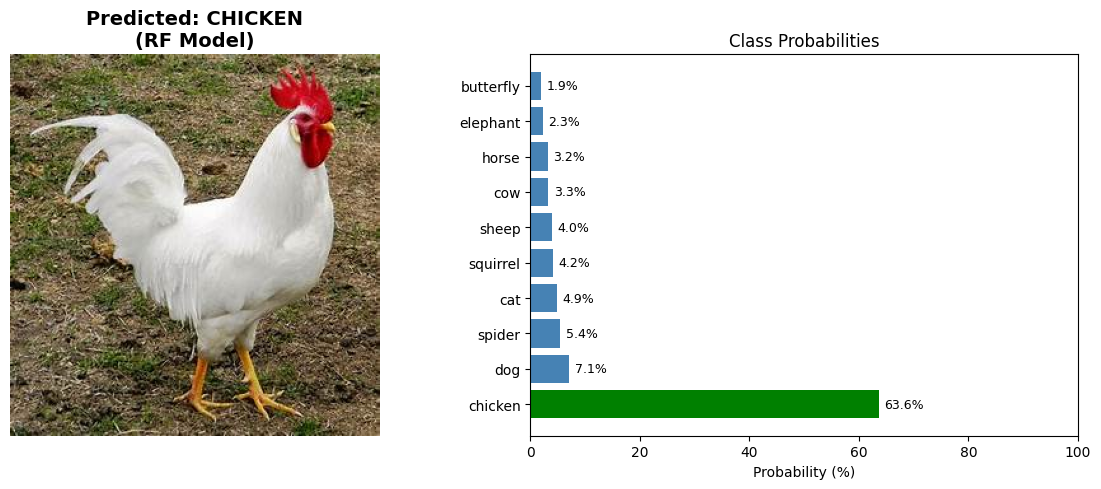


🎯 Prediction: CHICKEN
📊 Confidence: 63.62%


In [14]:
# Predict using Random Forest
if os.path.exists(IMAGE_PATH):
    result_rf = predict_animal(IMAGE_PATH, model='rf')
    display_prediction(result_rf)

## Compare Both Models

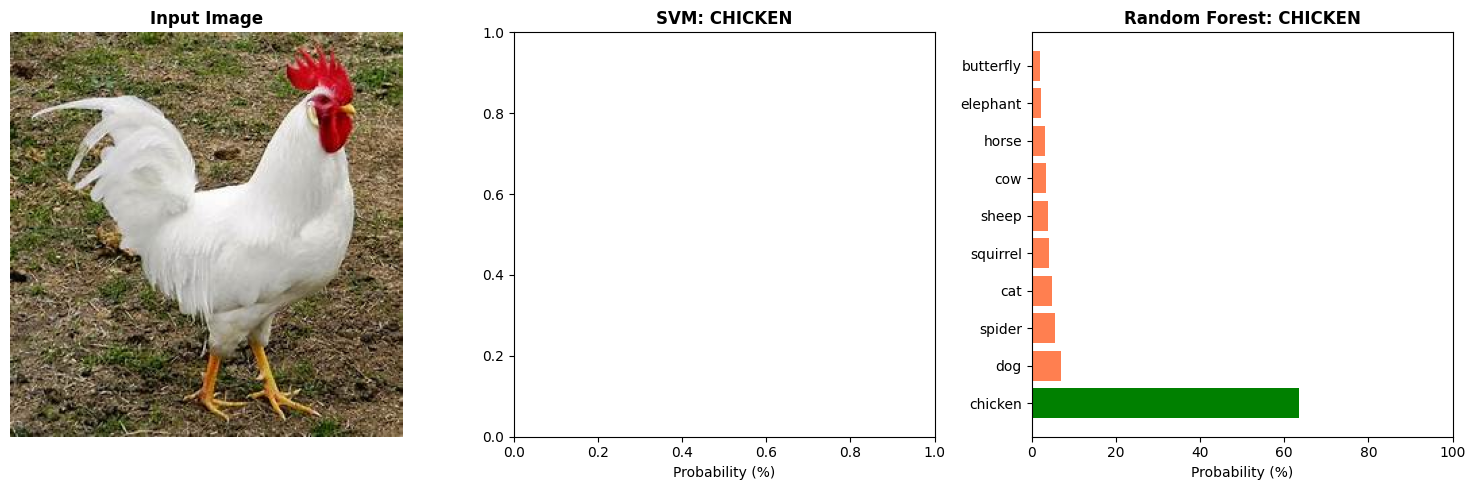


Model Comparison Summary
SVM Prediction:           CHICKEN
Random Forest Prediction: CHICKEN

✓ Both models agree!


In [15]:
def compare_models(image_path):
    """
    Compare predictions from both SVM and Random Forest models.
    """
    if not os.path.exists(image_path):
        print(f"⚠️ Image not found: {image_path}")
        return
    
    result_svm = predict_animal(image_path, model='svm')
    result_rf = predict_animal(image_path, model='rf')
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Display image
    axes[0].imshow(result_svm['image_display'])
    axes[0].set_title('Input Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # SVM probabilities
    classes = label_encoder.classes_
    if result_svm['probabilities'] is not None:
        sorted_idx = np.argsort(result_svm['probabilities'])[::-1]
        colors = ['green' if classes[i] == result_svm['predicted_class'] else 'steelblue' 
                  for i in sorted_idx]
        axes[1].barh([classes[i] for i in sorted_idx], 
                    [result_svm['probabilities'][i] * 100 for i in sorted_idx],
                    color=colors)
        axes[1].set_xlim(0, 100)
    axes[1].set_title(f'SVM: {result_svm["predicted_class"].upper()}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Probability (%)')
    
    # RF probabilities
    if result_rf['probabilities'] is not None:
        sorted_idx = np.argsort(result_rf['probabilities'])[::-1]
        colors = ['green' if classes[i] == result_rf['predicted_class'] else 'coral' 
                  for i in sorted_idx]
        axes[2].barh([classes[i] for i in sorted_idx], 
                    [result_rf['probabilities'][i] * 100 for i in sorted_idx],
                    color=colors)
        axes[2].set_xlim(0, 100)
    axes[2].set_title(f'Random Forest: {result_rf["predicted_class"].upper()}', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Probability (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*50)
    print("Model Comparison Summary")
    print("="*50)
    print(f"SVM Prediction:           {result_svm['predicted_class'].upper()}")
    print(f"Random Forest Prediction: {result_rf['predicted_class'].upper()}")
    
    if result_svm['predicted_class'] == result_rf['predicted_class']:
        print("\n✓ Both models agree!")
    else:
        print("\n⚠️ Models disagree - consider the context and confidence levels")

# Run comparison
compare_models(IMAGE_PATH)

## Batch Prediction

Predict multiple images at once.

In [16]:
def batch_predict(image_paths, model='svm'):
    """
    Predict multiple images and display results in a grid.
    
    Args:
        image_paths: List of image paths
        model: 'svm' or 'rf'
    """
    valid_paths = [p for p in image_paths if os.path.exists(p)]
    
    if not valid_paths:
        print("No valid image paths found.")
        return
    
    n_images = len(valid_paths)
    cols = min(4, n_images)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if n_images == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    results = []
    for i, path in enumerate(valid_paths):
        try:
            result = predict_animal(path, model=model)
            results.append(result)
            
            axes[i].imshow(result['image_display'])
            confidence = max(result['probabilities'])*100 if result['probabilities'] is not None else 0
            axes[i].set_title(f"{result['predicted_class'].upper()}\n({confidence:.1f}%)", 
                             fontsize=10, fontweight='bold')
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error:\n{str(e)[:30]}', 
                        ha='center', va='center')
            axes[i].axis('off')
    
    # Hide unused axes
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Batch Predictions ({model.upper()} Model)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return results


# Example usage - replace with your image paths
# image_list = [
#     'path/to/image1.jpg',
#     'path/to/image2.jpg',
#     'path/to/image3.jpg',
# ]
# batch_predict(image_list, model='svm')